# AAI-540 Group 3: AeroDelay Insights — Combined Modular Notebook

This notebook combines all ten project notebooks into one end-to-end workflow covering data ingestion, EDA, preprocessing, feature store, model monitor, baseline LR, XGBoost HPO, evaluation, and model registry/batch inference.

**Team Members:**
- Faisal Abdul Ghafour — Notebooks 01–06
- Narendra Iyer — Notebooks 07–10
- Aleena Gigi

**Table of Contents:**
1. [Shared Setup](#step0) — imports, session, S3 paths (run every session)
2. [S3 & Data Ingestion](#step1) — BTS CSV download (run once)
3. [Athena Setup](#step2) — database/table creation (idempotent)
4. [Exploratory Data Analysis](#step3)
5. [Preprocessing Pipeline](#step4) — SageMaker Processing Job (run once)
6. [Feature Store](#step5) — Feature Group creation (run once)
7. [Model Monitor Baseline](#step6) — baseline job (run once)
8. [Baseline Logistic Regression](#step7) — training job (run once)
9. [XGBoost + HPO](#step8) — training + tuning (run once)
10. [Model Evaluation](#step9)
11. [Model Registry + Batch Inference](#step10) — (run once)

> **Run guidance:** Cells tagged `# RUN-ONCE` launch cloud jobs or upload data. They are idempotent or guarded — safe to re-run but not required after first execution.

## Step 0: Shared Setup <a id='step0'></a>

**Run this section every new session** before anything else.  
All imports, AWS session variables, S3 paths, and Athena helpers are defined here once and reused throughout.

In [1]:
# ── Shared project configuration ──────────────────────────────
PROJECT_NAME  = 'aerodelay-insights'
GROUP_NAME    = 'AAI-540 Group 3'
AWS_REGION    = 'us-east-1'

# S3 bucket — update to your own Learner Lab bucket
S3_BUCKET  = 'sagemaker-us-east-1-151132426745'
S3_PREFIX  = 'airline-delay'

# Athena conventions
ATHENA_DATABASE = 'aerodelay'
ATHENA_TABLE    = 'flights'

# Modeling conventions
TARGET_COLUMN = 'arr_del15'
RANDOM_STATE  = 42
TEST_SIZE     = 0.2

print(f'Project : {GROUP_NAME} — {PROJECT_NAME}')
print(f'Region  : {AWS_REGION}')
print(f'S3 bucket: {S3_BUCKET}')

Project : AAI-540 Group 3 — aerodelay-insights
Region  : us-east-1
S3 bucket: sagemaker-us-east-1-151132426745


In [2]:
# ── All imports (single block) ────────────────────────────────
import boto3, os, io, json, time, tarfile, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import requests, zipfile
import joblib
import xgboost as xgb
import awswrangler as wr

# Disable Ray — use local execution only (avoids memory issues on ml.t3.medium)
wr.config.max_remote_workers = 0

from pyathena import connect
from IPython.display import Image, display

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

# sagemaker-core imports
from sagemaker.core.helper.session_helper import Session, get_execution_role
from sagemaker.core.image_uris import retrieve
from sagemaker.core.processing import ScriptProcessor, Processor
from sagemaker.core.shapes import (
    ProcessingInput, ProcessingS3Input,
    ProcessingOutput, ProcessingS3Output
)
from sagemaker.core.shapes.shapes import FeatureDefinition, OfflineStoreConfig, S3StorageConfig
import sagemaker.mlops.feature_store as fs

# sagemaker v3 train API (replaces legacy SKLearn/XGBoost estimators)
from sagemaker.train.model_trainer import ModelTrainer
from sagemaker.train.configs import (
    SourceCode, Compute, InputData, OutputDataConfig, StoppingCondition
)
from sagemaker.train.tuner import HyperparameterTuner
from sagemaker.serve.model_builder import ModelBuilder

print('All imports successful.')
print(f'awswrangler Ray workers: {wr.config.max_remote_workers} (local mode — no Ray)')


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


All imports successful.
awswrangler Ray workers: 0 (local mode — no Ray)


In [3]:
# ── AWS Session & clients ─────────────────────────────────────
sess   = Session()
bucket = sess.default_bucket()
role   = get_execution_role()
region = sess.boto_region_name

account_id = boto3.client('sts').get_caller_identity()['Account']

# boto3 clients — reused throughout
s3         = boto3.client('s3')
s3_client  = s3
sm         = boto3.client('sagemaker')
sm_client  = sm

# Feature Store session
boto_session         = boto3.Session(region_name=region)
featurestore_runtime = boto_session.client('sagemaker-featurestore-runtime', region_name=region)
feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=boto_session.client('sagemaker', region_name=region),
    sagemaker_featurestore_runtime_client=featurestore_runtime
)

print(f'Region  : {region}')
print(f'Account : {account_id}')
print(f'Bucket  : {bucket}')


Region  : us-east-1
Account : 151132426745
Bucket  : sagemaker-us-east-1-151132426745


In [4]:
# ── S3 path constants ─────────────────────────────────────────
s3_aerodelay        = f's3://{bucket}/airline-delay'
aerodelay_db        = ATHENA_DATABASE
aerodelay_table     = ATHENA_TABLE
aerodelay_s3_staging_dir = f's3://{bucket}/airline-delay/athena-results/'

%store s3_aerodelay
%store aerodelay_db
%store aerodelay_table
%store aerodelay_s3_staging_dir

print(f's3_aerodelay          : {s3_aerodelay}')
print(f'Athena DB             : {aerodelay_db}')
print(f'Athena table          : {aerodelay_table}')
print(f'Athena staging dir    : {aerodelay_s3_staging_dir}')

Stored 's3_aerodelay' (str)
Stored 'aerodelay_db' (str)
Stored 'aerodelay_table' (str)
Stored 'aerodelay_s3_staging_dir' (str)
s3_aerodelay          : s3://sagemaker-us-east-1-151132426745/airline-delay
Athena DB             : aerodelay
Athena table          : flights
Athena staging dir    : s3://sagemaker-us-east-1-151132426745/airline-delay/athena-results/


In [5]:
# ── Athena helper functions ───────────────────────────────────
conn = connect(region_name=region, s3_staging_dir=aerodelay_s3_staging_dir)

def run_select(sql):
    """Run a SELECT via Athena and return a pandas DataFrame."""
    return wr.athena.read_sql_query(
        sql=sql,
        database=aerodelay_db,
        s3_output=aerodelay_s3_staging_dir,
        ctas_approach=False
    )

def run_ddl(sql):
    """Run a DDL statement via Athena and wait until it finishes."""
    return wr.athena.start_query_execution(
        sql=sql,
        database=aerodelay_db,
        s3_output=aerodelay_s3_staging_dir,
        wait=True
    )

print('Athena helpers ready.')

Athena helpers ready.


## Step 1: S3 Data Ingestion <a id='step1'></a>

**Source:** `01_s3_setup.ipynb`  
Downloads Q1 2024 airline on-time performance CSVs from BTS and uploads to S3.

**RUN-ONCE** — CSVs persist in S3:
```
airline-delay/raw/year=2024/month=01/flights.csv  (246 MB)
airline-delay/raw/year=2024/month=02/flights.csv  (234 MB)
airline-delay/raw/year=2024/month=03/flights.csv  (267 MB)
```

In [6]:
# RUN-ONCE: Download BTS CSVs and upload to S3
# Skip if raw CSVs already exist in S3 (check with !aws s3 ls below)

files = [
    ('2024_1', 'year=2024/month=01'),
    ('2024_2', 'year=2024/month=02'),
    ('2024_3', 'year=2024/month=03'),
]
base_url = 'https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{}.zip'

for suffix, s3_prefix in files:
    key = f'airline-delay/raw/{s3_prefix}/flights.csv'
    # Skip if already uploaded
    try:
        s3.head_object(Bucket=bucket, Key=key)
        print(f'{suffix}: already in S3, skipping.')
        continue
    except Exception:
        pass
    url = base_url.format(suffix)
    print(f'Downloading {suffix}...')
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    csv_name = [n for n in z.namelist() if n.endswith('.csv')][0]
    csv_bytes = z.read(csv_name)
    s3.put_object(Bucket=bucket, Key=key, Body=csv_bytes)
    print(f'  uploaded → s3://{bucket}/{key} ({len(csv_bytes)//1_000_000} MB)')

print('Done.')

2024_1: already in S3, skipping.


2024_2: already in S3, skipping.


2024_3: already in S3, skipping.
Done.


In [7]:
# Verify S3 raw data
!aws s3 ls {s3_aerodelay}/raw/ --recursive --human-readable

2026-06-21 08:48:04  235.4 MiB airline-delay/raw/year=2024/month=01/flights.csv
2026-06-21 08:48:18  223.5 MiB airline-delay/raw/year=2024/month=02/flights.csv
2026-06-21 08:48:33  255.3 MiB airline-delay/raw/year=2024/month=03/flights.csv


## Step 2: Athena Setup <a id='step2'></a>

**Source:** `02_athena_setup.ipynb`  
Creates the Athena database and external table over the raw S3 CSVs.  
All DDL operations use `IF NOT EXISTS` — **idempotent and safe to re-run**.

In [8]:
# Fix Athena BAD_DATA — blank strings in numeric delay columns → NULL
# Idempotent: safe to re-run
fix_sql = f"""
ALTER TABLE {aerodelay_db}.{aerodelay_table}
SET TBLPROPERTIES ('use.null.for.invalid.data'='true')
"""
# Create DB and table first if they don't exist, then apply fix
run_ddl(f'CREATE DATABASE IF NOT EXISTS {aerodelay_db}')
print('Database ready.')

Database ready.


In [9]:
# Create external table
stmt = """CREATE EXTERNAL TABLE IF NOT EXISTS {db}.{tbl} (
      Year INT, Quarter INT, Month INT, DayofMonth INT, DayOfWeek INT,
      FlightDate STRING, Reporting_Airline STRING,
      DOT_ID_Reporting_Airline INT, IATA_CODE_Reporting_Airline STRING,
      Tail_Number STRING, Flight_Number_Reporting_Airline INT,
      OriginAirportID INT, OriginAirportSeqID INT, OriginCityMarketID INT,
      Origin STRING, OriginCityName STRING, OriginState STRING,
      OriginStateFips INT, OriginStateName STRING, OriginWac INT,
      DestAirportID INT, DestAirportSeqID INT, DestCityMarketID INT,
      Dest STRING, DestCityName STRING, DestState STRING,
      DestStateFips INT, DestStateName STRING, DestWac INT,
      CRSDepTime INT, DepTime DOUBLE, DepDelay DOUBLE,
      DepDelayMinutes DOUBLE, DepDel15 DOUBLE, DepartureDelayGroups INT,
      DepTimeBlk STRING, TaxiOut DOUBLE, WheelsOff DOUBLE,
      WheelsOn DOUBLE, TaxiIn DOUBLE, CRSArrTime INT,
      ArrTime DOUBLE, ArrDelay DOUBLE, ArrDelayMinutes DOUBLE,
      ArrDel15 DOUBLE, ArrivalDelayGroups INT, ArrTimeBlk STRING,
      Cancelled DOUBLE, CancellationCode STRING, Diverted DOUBLE,
      CRSElapsedTime DOUBLE, ActualElapsedTime DOUBLE, AirTime DOUBLE,
      Flights DOUBLE, Distance DOUBLE, DistanceGroup INT,
      CarrierDelay DOUBLE, WeatherDelay DOUBLE, NASDelay DOUBLE,
      SecurityDelay DOUBLE, LateAircraftDelay DOUBLE
  )
  ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
  WITH SERDEPROPERTIES ("separatorChar"=",","quoteChar"="\\"")
  STORED AS TEXTFILE
  LOCATION '{loc}/raw/'
  TBLPROPERTIES ('skip.header.line.count'='1')
""".format(db=aerodelay_db, tbl=aerodelay_table, loc=s3_aerodelay)

run_ddl(stmt)
print('Table ready.')

# Apply BAD_DATA fix
run_ddl(f"ALTER TABLE {aerodelay_db}.{aerodelay_table} SET TBLPROPERTIES ('use.null.for.invalid.data'='true')")
print('BAD_DATA fix applied.')

Table ready.


BAD_DATA fix applied.


In [10]:
# Validate: query 5 rows
run_select(f'SELECT * FROM {aerodelay_db}.{aerodelay_table} LIMIT 5')

[06/21/26 13:13:32] INFO     Initializing a Ray instance                                               ]8;id=446185;file:///opt/conda/lib/python3.12/site-packages/awswrangler/distributed/ray/_core.py\_core.py]8;;\:]8;id=446186;file:///opt/conda/lib/python3.12/site-packages/awswrangler/distributed/ray/_core.py#202\202]8;;\

2026-06-21 13:13:35,998	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 408920064 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.76gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-06-21 13:13:38,224	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


,year,quarter,month,dayofmonth,dayofweek,flightdate,reporting_airline,dot_id_reporting_airline,iata_code_reporting_airline,tail_number,...,actualelapsedtime,airtime,flights,distance,distancegroup,carrierdelay,weatherdelay,nasdelay,securitydelay,lateaircraftdelay
0,2024,1,3,6,3,2024-03-06,YX,20452,YX,N757YX,...,95.0,71.0,1.0,476.0,2,NaN,NaN,NaN,NaN,NaN
1,2024,1,3,6,3,2024-03-06,YX,20452,YX,N748YX,...,111.0,78.0,1.0,536.0,3,NaN,NaN,NaN,NaN,NaN
2,2024,1,3,6,3,2024-03-06,YX,20452,YX,N746YX,...,136.0,107.0,1.0,725.0,3,NaN,NaN,NaN,NaN,NaN
3,2024,1,3,6,3,2024-03-06,YX,20452,YX,N657RW,...,118.0,89.0,1.0,589.0,3,52.0,0.0,0.0,0.0,0.0
4,2024,1,3,6,3,2024-03-06,YX,20452,YX,N743YX,...,84.0,63.0,1.0,441.0,2,NaN,NaN,NaN,NaN,NaN


In [11]:
# Confirm table registered in Glue catalog
wr.catalog.tables(database=aerodelay_db)

,Database,Table,Description,TableType,Columns,Partitions
0,aerodelay,flights,,EXTERNAL_TABLE,"year, quarter, month, dayofmonth, dayofweek, f...",


## Step 3: Exploratory Data Analysis <a id='step3'></a>

**Source:** `03_eda.ipynb`  

**Strategy:** Load full 1.6M rows chunked by month to avoid memory issues.  
Charts use a 100K random sample (verified representative at 20.3% delay rate).  
Departure-hour analysis uses all 1.6M rows for accuracy.

In [12]:
# Load full dataset chunked by month — avoids single large Athena download
dfs = []
for month in [1, 2, 3]:
    q = f"""
        SELECT flightdate, year, quarter, month, dayofmonth, dayofweek,
               reporting_airline, origin, dest, originstate, deststate,
               crsdeptime, crsarrtime, crselapsedtime, distance, distancegroup,
               deptimeblk, arrtimeblk, arrdel15, cancelled, diverted,
               depdelay, arrdelay, airtime
        FROM {aerodelay_db}.{aerodelay_table}
        WHERE cancelled = 0 AND diverted = 0 AND arrdelay IS NOT NULL
        AND month = {month}
    """
    print(f'Loading month {month}...')
    df_m = run_select(q)
    print(f'  month {month}: {df_m.shape[0]:,} rows')
    dfs.append(df_m)

base_df = pd.concat(dfs, ignore_index=True)
base_df['dep_hour'] = base_df['crsdeptime'] // 100

print(f'\nFull dataset: {base_df.shape[0]:,} rows x {base_df.shape[1]} cols')
print(f'Delay rate  : {base_df["arrdel15"].mean():.1%}')
base_df.head()

Loading month 1...


  month 1: 525,370 rows
Loading month 2...


  month 2: 515,269 rows
Loading month 3...


  month 3: 585,413 rows



Full dataset: 1,626,052 rows x 25 cols
Delay rate  : 20.3%


,flightdate,year,quarter,month,dayofmonth,dayofweek,reporting_airline,origin,dest,originstate,...,distancegroup,deptimeblk,arrtimeblk,arrdel15,cancelled,diverted,depdelay,arrdelay,airtime,dep_hour
0,2024-01-08,2024,1,1,8,1,WN,FLL,HOU,FL,...,4,1000-1059,1200-1259,1.0,0.0,0.0,141.0,184.0,192.0,10
1,2024-01-08,2024,1,1,8,1,WN,FLL,HOU,FL,...,4,1800-1859,2000-2059,1.0,0.0,0.0,98.0,123.0,167.0,18
2,2024-01-08,2024,1,1,8,1,WN,FLL,HOU,FL,...,4,0600-0659,0700-0759,1.0,0.0,0.0,31.0,35.0,154.0,6
3,2024-01-08,2024,1,1,8,1,WN,FLL,IND,FL,...,5,2000-2059,2300-2359,0.0,0.0,0.0,24.0,13.0,133.0,20
4,2024-01-08,2024,1,1,8,1,WN,FLL,MCI,FL,...,5,1600-1659,1900-1959,0.0,0.0,0.0,1.0,-11.0,170.0,16


In [13]:
# Dataset info
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1626052 entries, 0 to 1626051
Data columns (total 25 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   flightdate         1626052 non-null  string 
 1   year               1626052 non-null  Int32  
 2   quarter            1626052 non-null  Int32  
 3   month              1626052 non-null  Int32  
 4   dayofmonth         1626052 non-null  Int32  
 5   dayofweek          1626052 non-null  Int32  
 6   reporting_airline  1626052 non-null  string 
 7   origin             1626052 non-null  string 
 8   dest               1626052 non-null  string 
 9   originstate        1626052 non-null  string 
 10  deststate          1626052 non-null  string 
 11  crsdeptime         1626052 non-null  Int32  
 12  crsarrtime         1626052 non-null  Int32  
 13  crselapsedtime     1626052 non-null  float64
 14  distance           1626052 non-null  float64
 15  distancegroup      1626052 non-n

### Target Variable: `arrdel15`

**Objective:** Predict whether a flight will arrive **≥15 minutes late**.

- `arrdel15 = 1` → Delayed
- `arrdel15 = 0` → On time

**Class distribution:**

In [14]:
print(base_df['arrdel15'].value_counts(normalize=True).round(4).to_string())
print(f'\nClass imbalance ratio: {(base_df["arrdel15"]==0).sum() / (base_df["arrdel15"]==1).sum():.1f}:1')

arrdel15
0.0    0.7968
1.0    0.2032

Class imbalance ratio: 3.9:1


**Imbalance implications:**
- 80% on-time / 20% delayed — 4:1 imbalance
- A naive "always on-time" model achieves 80% accuracy — meaningless
- Use **Recall** and **F1-score** as primary metrics
- Set `scale_pos_weight=4` in XGBoost

In [15]:
# Missing values check
missing = base_df.isnull().sum()
missing_df = missing[missing > 0]
if missing_df.empty:
    print('Zero missing values in all columns.')
else:
    print(missing_df)

Zero missing values in all columns.


**Result:** Zero missing values after filtering cancelled/diverted flights. No imputation needed.

In [16]:
# 100K sample for visualizations — verified representative
df_eda = base_df.sample(n=100_000, random_state=42).copy()
df_eda = df_eda.drop(columns=['cancelled', 'diverted'])
df_eda['dep_hour'] = df_eda['crsdeptime'] // 100
print(f'EDA sample shape : {df_eda.shape}')
print(f'Delay rate sample: {df_eda["arrdel15"].mean():.1%} (full dataset: {base_df["arrdel15"].mean():.1%})')

EDA sample shape : (100000, 23)
Delay rate sample: 20.3% (full dataset: 20.3%)


In [17]:
# Cardinality of categorical columns
cats = ['reporting_airline', 'origin', 'dest', 'originstate', 'deststate', 'deptimeblk']
for col in cats:
    print(f'{col:25s}: {df_eda[col].nunique()} unique values')

reporting_airline        : 15 unique values
origin                   : 334 unique values
dest                     : 332 unique values
originstate              : 52 unique values
deststate                : 52 unique values
deptimeblk               : 19 unique values


**Cardinality findings:**
- `origin` / `dest`: 331/330 unique — use **target encoding** (historical delay rate)
- `reporting_airline`: 15 unique — use **label encoding**
- `originstate` / `deststate`: 52 unique — use **label encoding**
- `deptimeblk`: 19 unique — use **label encoding**

In [18]:
# Numeric distributions
print(df_eda[['distance', 'crselapsedtime', 'crsdeptime']].describe().round(1))

       distance  crselapsedtime  crsdeptime
count  100000.0        100000.0    100000.0
mean      834.2           148.4      1325.5
std       588.5            72.9       490.1
min        31.0            25.0         5.0
25%       403.0            95.0       909.0
50%       694.0           133.0      1322.0
75%      1069.0           180.0      1735.0
max      5095.0           706.0      2359.0


**Numeric findings:**
- `distance`: min=31, max=5,095, mean=836 — right-skewed, no outliers. StandardScaler for LR only.
- `crselapsedtime`: min=6, max=710 — normal range. Scale for LR only.
- `crsdeptime`: HHMM integer → convert to `dep_hour = crsdeptime // 100` in preprocessing.

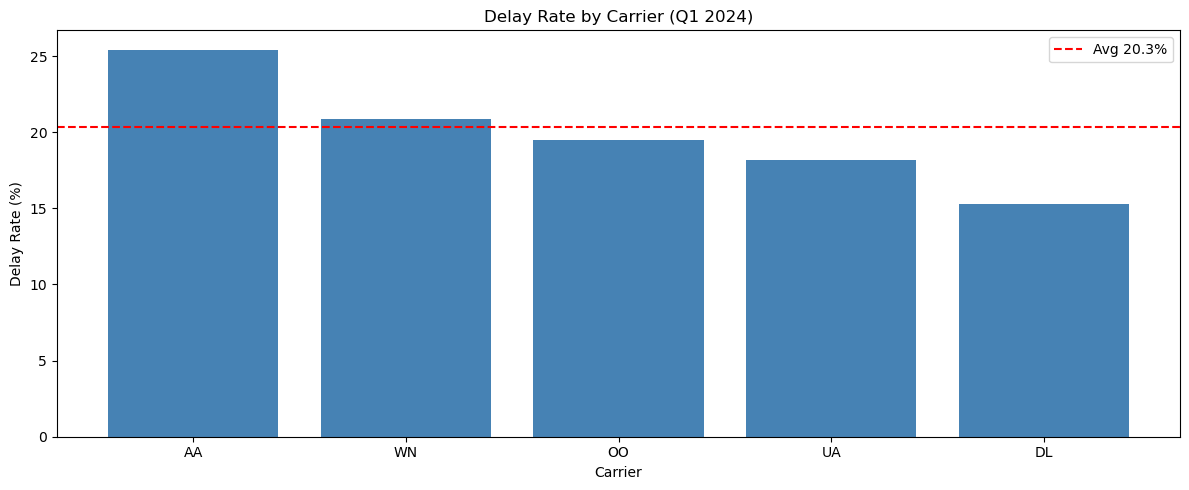

In [19]:
# Delay rate by carrier
carrier_stats = (
    df_eda.groupby('reporting_airline')['arrdel15']
    .agg(['mean','count'])
    .query('count > 5000')
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(carrier_stats.index, carrier_stats['mean'] * 100, color='steelblue')
ax.axhline(base_df['arrdel15'].mean() * 100, color='red', linestyle='--',
           label=f"Avg {base_df['arrdel15'].mean():.1%}")
ax.set_xlabel('Carrier'); ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Carrier (Q1 2024)')
ax.legend(); plt.tight_layout()
plt.savefig('delay_by_carrier.png', dpi=100); plt.show()

**Carrier findings:**
- AA (American): ~25% — highest (+4.7% above avg)
- DL (Delta): ~15.5% — lowest (-4.8% below avg)
- WN, OO, UA: near average (~19–21%)
- 10pp spread confirms `reporting_airline` is a useful feature
- **Decision:** Label encode (15 values)

[06/21/26 13:14:13] INFO     Using categorical units to plot a list of strings that are all         ]8;id=446193;file:///opt/conda/lib/python3.12/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=446194;file:///opt/conda/lib/python3.12/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=446199;file:///opt/conda/lib/python3.12/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=446200;file:///opt/conda/lib/python3.12/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

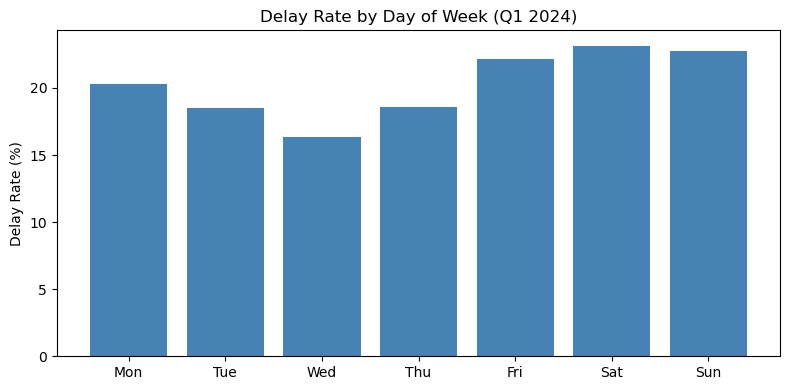

In [20]:
# Delay rate by day of week
dow_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
dow_stats = df_eda.groupby('dayofweek')['arrdel15'].mean() * 100
dow_stats.index = dow_stats.index.map(dow_map)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_stats.index, dow_stats.values, color='steelblue')
ax.set_ylabel('Delay Rate (%)'); ax.set_title('Delay Rate by Day of Week (Q1 2024)')
plt.tight_layout(); plt.savefig('delay_by_dow.png', dpi=100); plt.show()

**Day-of-week findings:**
- Wednesday ~17% (lowest) — mid-week least congested
- Saturday/Sunday ~23% (highest) — weekend travel peak
- Fri ~22% — end-of-week surge
- **Decision:** Keep `dayofweek`. Add `is_weekend` binary (Fri/Sat/Sun=1).

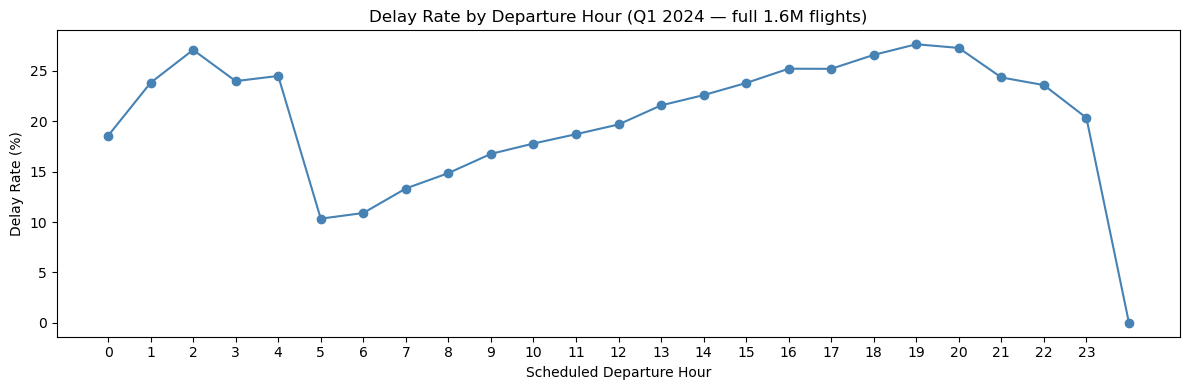

In [21]:
# Delay rate by departure hour — full 1.6M dataset
hour_stats = base_df.groupby('dep_hour')['arrdel15'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_stats.index, hour_stats.values, marker='o', color='steelblue')
ax.set_xlabel('Scheduled Departure Hour'); ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Departure Hour (Q1 2024 — full 1.6M flights)')
ax.set_xticks(range(0, 24)); plt.tight_layout()
plt.savefig('delay_by_hour.png', dpi=100); plt.show()

**Departure hour findings:**
- classic pattern: 5AM lowest at ~10%
- 19-20 (7-8PM) highest at ~27%
- hour 23 drops to ~0% due to very few late-night flights
- **Decision:** `dep_hour` is a strong feature. Keep as continuous (0–23).

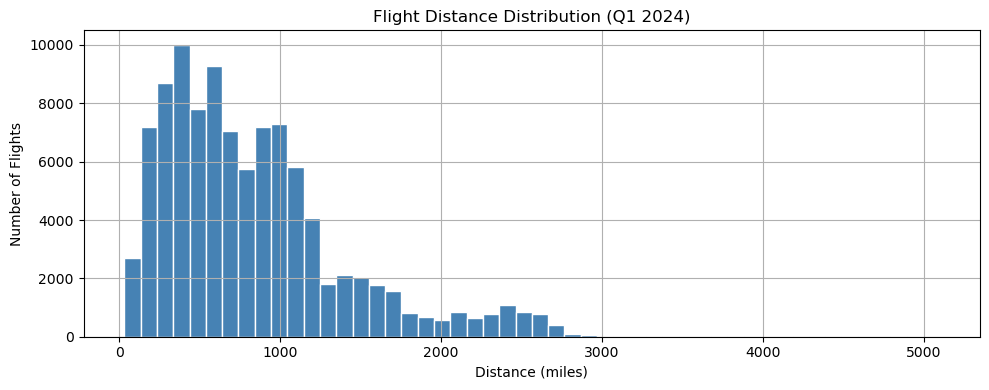

count    1626052.0
mean         836.6
std          591.0
min           31.0
25%          404.0
50%          696.0
75%         1072.0
max         5095.0
Name: distance, dtype: float64


In [22]:
# Distance distribution
fig, ax = plt.subplots(figsize=(10, 4))
df_eda['distance'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Distance (miles)'); ax.set_ylabel('Number of Flights')
ax.set_title('Flight Distance Distribution (Q1 2024)')
plt.tight_layout(); plt.savefig('distance_dist.png', dpi=100); plt.show()
print(base_df['distance'].describe().round(1))

**Distance findings:**
- Right-skewed: majority <1,000 miles, long tail to 5,095 miles (Hawaii/Alaska)
- No outliers — all valid domestic routes
- **Decision:** No capping. StandardScaler for LR only. Drop `distancegroup` (redundant).

## EDA Findings Report

### 1. Dataset Overview
| Metric | Value |
|---|---|
| Raw files | 3 monthly CSVs (Jan–Mar 2024) |
| Total raw flights | 1,658,259 |
| After filtering cancelled + diverted | 1,626,052 |
| Columns selected for modeling | 22 |
| Missing values | 0 |

### 2. Class Balance
| Class | Count | % |
|---|---|---|
| On Time (0) | 1,295,574 | 80.4% |
| Delayed (1) | 330,478 | 19.6% |

**Decision:** `scale_pos_weight=4`, evaluate on Recall + F1.

### 3. Feature Engineering Decisions
| Transformation | Input | Output | Reason |
|---|---|---|---|
| Discretization | `crsdeptime` (HHMM) | `dep_hour` (0–23) | Model-friendly hour |
| Binary | `dayofweek` | `is_weekend` (0/1) | Fri/Sat/Sun effect |
| Combination | `origin`+`dest` | `route` | Route-level delay patterns |
| Target encoding | `origin`,`dest`,`route` | `*_delay_rate` | High-cardinality encoding |
| Target encoding | `reporting_airline`,`dep_hour` | `*_delay_rate` | Historical performance |
| Drop | leakage columns | — | `arrdelay`, `depdelay`, post-flight cols |
| Drop | `cancelled`,`diverted` | — | All = 0 after filtering |
| Drop | `quarter`,`distancegroup` | — | Redundant with month/distance |

### 4. Final Feature List
```python
FINAL_FEATURES = [
    'month', 'dayofweek', 'dayofmonth', 'dep_hour', 'is_weekend',
    'reporting_airline', 'origin', 'dest', 'route',
    'distance', 'crselapsedtime',
    'carrier_delay_rate', 'origin_delay_rate', 'dest_delay_rate',
    'route_delay_rate', 'hour_delay_rate',
]
TARGET = 'arrdel15'
```

## Step 4: Preprocessing Pipeline <a id='step4'></a>

**Source:** `04_preprocessing.ipynb`  
Runs a SageMaker Processing Job on `ml.m5.large` executing `preprocessing/preprocess.py`.

**RUN-ONCE** — output parquet files persist in S3:
- `airline-delay/training/data.parquet` — 650K rows
- `airline-delay/validation/data.parquet`
- `airline-delay/test/data.parquet`
- `airline-delay/production_simulation/data.parquet`

The cell checks if outputs already exist before launching a new job.

In [23]:
# Retrieve SKLearn container image
image_string = retrieve(framework='sklearn', region=region, version='1.2-1')
print(f'SKLearn image: {image_string}')
print(f'Working dir  : {os.getcwd()}')

[06/21/26 13:14:14] INFO     Defaulting to only available Python version: py3                     ]8;id=446207;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=446208;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=446214;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=446215;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#539\539]8;;\

SKLearn image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.2-1-cpu-py3
Working dir  : /home/sagemaker-user/Airline-Delay-Prediction-with-AWS-SageMaker


In [24]:
# RUN-ONCE: Launch preprocessing job only if outputs don't exist
training_key = 'airline-delay/training/data.parquet'
try:
    s3.head_object(Bucket=bucket, Key=training_key)
    print('Preprocessing outputs already exist in S3. Skipping job.')
    print(f'  s3://{bucket}/{training_key}')
except Exception:
    print('Launching SageMaker Processing Job...')
    processor = ScriptProcessor(
        command=['python3'],
        image_uri=image_string,
        role=role,
        instance_count=1,
        instance_type='ml.m5.large',
        sagemaker_session=sess
    )
    processor.run(
        code='preprocessing/preprocess.py',
        inputs=[ProcessingInput(
            input_name='aerodelay_raw_input',
            s3_input=ProcessingS3Input(
                s3_uri=f'{s3_aerodelay}/raw/',
                local_path='/opt/ml/processing/input',
                s3_data_type='S3Prefix',
                s3_input_mode='File'
            )
        )],
        outputs=[
            ProcessingOutput(output_name='train_data',
                s3_output=ProcessingS3Output(local_path='/opt/ml/processing/output/train',
                    s3_uri=f'{s3_aerodelay}/training/', s3_upload_mode='EndOfJob')),
            ProcessingOutput(output_name='validation_data',
                s3_output=ProcessingS3Output(local_path='/opt/ml/processing/output/validation',
                    s3_uri=f'{s3_aerodelay}/validation/', s3_upload_mode='EndOfJob')),
            ProcessingOutput(output_name='test_data',
                s3_output=ProcessingS3Output(local_path='/opt/ml/processing/output/test',
                    s3_uri=f'{s3_aerodelay}/test/', s3_upload_mode='EndOfJob')),
            ProcessingOutput(output_name='production_simulation_data',
                s3_output=ProcessingS3Output(local_path='/opt/ml/processing/output/production_simulation',
                    s3_uri=f'{s3_aerodelay}/production_simulation/', s3_upload_mode='EndOfJob')),
        ]
    )
    print('Processing job completed.')

Preprocessing outputs already exist in S3. Skipping job.
  s3://sagemaker-us-east-1-151132426745/airline-delay/training/data.parquet


In [25]:
# Verify all 4 splits exist
for split in ['training', 'validation', 'test', 'production_simulation']:
    resp = s3.list_objects_v2(Bucket=bucket, Prefix=f'airline-delay/{split}/')
    files = [o['Key'] for o in resp.get('Contents', [])]
    size  = resp.get('Contents', [{}])[0].get('Size', 0) / 1024 / 1024 if resp.get('Contents') else 0
    print(f'{split:30s}: {files[0] if files else "NOT FOUND"} ({size:.1f} MB)')

training                      : airline-delay/training/data.parquet (8.7 MB)
validation                    : airline-delay/validation/data.parquet (2.2 MB)
test                          : airline-delay/test/data.parquet (2.2 MB)
production_simulation         : airline-delay/production_simulation/data.parquet (8.6 MB)


### Processing Job Architecture

When `processor.run()` executes, SageMaker orchestrates 6 automated stages:

1. **Code Staging** — SDK uploads `preprocess.py` to a unique S3 path
2. **Provisioning** — SageMaker launches an isolated `ml.m5.large` EC2 instance
3. **Container Init** — pulls SKLearn ECR image, downloads script, mounts raw data at `/opt/ml/processing/input`
4. **Execution** — `python3 preprocess.py` runs: feature engineering, target encoding, train/val/test/prod split, writes parquet to `/opt/ml/processing/output/`
5. **S3 Sync** — outputs uploaded to project S3 paths
6. **Termination** — instance auto-terminated; you pay only for minutes used

## Step 5: Feature Store Integration <a id='step5'></a>

**Source:** `05_feature_store.ipynb`  

**Architecture decision:** This project uses the **offline store only**.  
All downstream notebooks read training data via `wr.s3.read_parquet()` — not the online store API.  
Online ingestion (`fs.ingest_dataframe`) is **skipped** — it takes 30+ minutes with no benefit for batch inference.

**RUN-ONCE** — Feature Group creation only. Idempotent.

In [26]:
# Load training data for Feature Group schema definition
train_df = wr.s3.read_parquet(f'{s3_aerodelay}/training/data.parquet')
print(f'Train shape: {train_df.shape}')
print(train_df.dtypes)
train_df.head()

Train shape: (650420, 20)
year                           Int64
month                          Int64
dayofmonth                     Int64
dayofweek                      Int64
reporting_airline              Int64
origin                string[python]
dest                  string[python]
originstate                    Int64
deststate                      Int64
crselapsedtime               float64
distance                     float64
arrdel15                       Int64
dep_hour                       Int64
is_weekend                     Int64
route                 string[python]
carrier_delay_rate           float64
origin_delay_rate            float64
dest_delay_rate              float64
route_delay_rate             float64
hour_delay_rate              float64
dtype: object


,year,month,dayofmonth,dayofweek,reporting_airline,origin,dest,originstate,deststate,crselapsedtime,distance,arrdel15,dep_hour,is_weekend,route,carrier_delay_rate,origin_delay_rate,dest_delay_rate,route_delay_rate,hour_delay_rate
0,2024,1,1,1,13,ROC,BWI,32,18,70.0,277.0,0,17,0,ROC_BWI,0.227525,0.224472,0.208520,0.137931,0.274622
1,2024,1,1,1,2,SEA,FAI,48,0,235.0,1533.0,0,22,0,SEA_FAI,0.266612,0.244266,0.250000,0.240642,0.217592
2,2024,1,1,1,1,MIA,DEN,7,5,270.0,1709.0,1,16,0,MIA_DEN,0.273395,0.310255,0.199440,0.262411,0.267768
3,2024,1,1,1,2,FAI,SEA,0,48,221.0,1533.0,0,2,0,FAI_SEA,0.266612,0.263393,0.204501,0.284946,0.217949
4,2024,1,1,1,2,SEA,FAI,48,0,235.0,1533.0,0,20,0,SEA_FAI,0.266612,0.244266,0.250000,0.240642,0.274706


In [27]:
# Add Feature Store required columns
train_df = train_df.copy()
train_df['flight_id']  = [str(i) for i in range(len(train_df))]
train_df['event_time'] = '2024-01-01T00:00:00Z'

# Fix dtypes — Feature Store requires no Int64/string ambiguity
for col in ['year','month','dayofmonth','dayofweek','reporting_airline',
            'originstate','deststate','dep_hour','is_weekend','arrdel15']:
    train_df[col] = train_df[col].astype(int)
for col in ['crselapsedtime','distance','carrier_delay_rate','origin_delay_rate',
            'dest_delay_rate','route_delay_rate','hour_delay_rate']:
    train_df[col] = train_df[col].astype(float)
for col in ['origin','dest','route']:
    train_df[col] = train_df[col].astype(str)

print(f'Shape with metadata cols: {train_df.shape}')
print(train_df[['flight_id','event_time']].head(2))

Shape with metadata cols: (650420, 22)
  flight_id            event_time
0         0  2024-01-01T00:00:00Z
1         1  2024-01-01T00:00:00Z


In [28]:
# RUN-ONCE: Create Feature Group (idempotent)
feature_group_name             = 'aerodelay-flight'
record_identifier_feature_name = 'flight_id'
event_time_feature_name        = 'event_time'

try:
    existing = sm.describe_feature_group(FeatureGroupName=feature_group_name)
    print(f"Feature Group '{feature_group_name}' already exists. Skipping creation.")
    print(f"  Status: {existing['FeatureGroupStatus']}")
except sm.exceptions.ResourceNotFound:
    feature_definitions = fs.load_feature_definitions_from_dataframe(data_frame=train_df)
    feature_group = fs.FeatureGroup.create(
        feature_group_name=feature_group_name,
        record_identifier_feature_name=record_identifier_feature_name,
        event_time_feature_name=event_time_feature_name,
        feature_definitions=feature_definitions,
        offline_store_config=OfflineStoreConfig(
            s3_storage_config=S3StorageConfig(s3_uri=f'{s3_aerodelay}/feature-store/')
        ),
        role_arn=role,
    )
    print('Waiting for Feature Group...')
    while True:
        status = sm.describe_feature_group(FeatureGroupName=feature_group_name)['FeatureGroupStatus']
        print(f'  Status: {status}')
        if status == 'Created': break
        if status == 'CreateFailed': raise RuntimeError('Feature Group creation failed')
        time.sleep(10)
    print('Feature Group ready.')

Feature Group 'aerodelay-flight' already exists. Skipping creation.
  Status: Created


### Online Ingestion — Intentionally Skipped

The Feature Store has two stores:
- **Online store** — low-latency `get_record` API for real-time inference. **Not used in this project.**
- **Offline store** — S3-backed parquet queryable via Athena. **This is what notebooks 07–10 use.**

`fs.ingest_dataframe` takes 20–30 minutes to push 650K records to the online store.  
Since all reads go through `wr.s3.read_parquet()`, this step is unnecessary and is skipped.

To enable online ingestion (if needed for real-time serving), uncomment:
```python
# fs.ingest_dataframe(feature_group_name=feature_group_name, data_frame=train_df, max_workers=4)
```

In [29]:
# Verify Feature Group and retrieve offline store metadata
desc       = sm.describe_feature_group(FeatureGroupName=feature_group_name)
ft_table   = desc['OfflineStoreConfig']['DataCatalogConfig']['TableName']
ft_database = desc['OfflineStoreConfig']['DataCatalogConfig']['Database']

print(f"Feature Group Status : {desc['FeatureGroupStatus']}")
print(f"Offline S3 URI       : {desc['OfflineStoreConfig']['S3StorageConfig']['S3Uri']}")
print(f"Glue table           : {ft_database}.{ft_table}")

%store ft_database ft_table

Feature Group Status : Created
Offline S3 URI       : s3://sagemaker-us-east-1-151132426745/airline-delay/feature-store/
Glue table           : sagemaker_featurestore.aerodelay_flight_1781963564
Stored 'ft_database' (str)
Stored 'ft_table' (str)


## Step 6: Model Monitor Baseline <a id='step6'></a>

**Source:** `06_model_monitor.ipynb`  
Runs the SageMaker Model Monitor baseline job to profile training features and generate `statistics.json` / `constraints.json`.

**RUN-ONCE** — baseline outputs persist in S3:
- `airline-delay/model-monitor/baseline-input/baseline.csv`
- `airline-delay/model-monitor/baseline-output/statistics.json`
- `airline-delay/model-monitor/baseline-output/constraints.json`

The cell checks if outputs exist before launching a new job.

### What Model Monitor does

Profiles each feature in the training dataset to establish "normal" statistical ranges.  
In production, new inference data is compared against these baselines to detect **data drift**.

**Outputs per feature:**
- Mean, std, min, max, quantiles
- Missing value rate
- Distribution histograms (for categoricals)

In [30]:
# Prepare baseline: training features only (no target)
baseline_df = train_df.drop(columns=['arrdel15', 'flight_id', 'event_time'], errors='ignore')
print(f'Baseline shape : {baseline_df.shape}')
print(f'Columns        : {list(baseline_df.columns)}')

Baseline shape : (650420, 19)
Columns        : ['year', 'month', 'dayofmonth', 'dayofweek', 'reporting_airline', 'origin', 'dest', 'originstate', 'deststate', 'crselapsedtime', 'distance', 'dep_hour', 'is_weekend', 'route', 'carrier_delay_rate', 'origin_delay_rate', 'dest_delay_rate', 'route_delay_rate', 'hour_delay_rate']


In [31]:
# RUN-ONCE: Save baseline CSV to S3 and run baseline job
baseline_s3_path   = f'{s3_aerodelay}/model-monitor/baseline-input/baseline.csv'
baseline_output_s3 = f'{s3_aerodelay}/model-monitor/baseline-output/'

# Check if baseline output already exists
existing_files = wr.s3.list_objects(baseline_output_s3) if True else []
stats_key = 'airline-delay/model-monitor/baseline-output/statistics.json'
try:
    s3.head_object(Bucket=bucket, Key=stats_key)
    print('Baseline output already exists. Skipping baseline job.')
    print(f'  {baseline_output_s3}')
except Exception:
    print('Saving baseline CSV to S3...')
    wr.s3.to_csv(df=baseline_df, path=baseline_s3_path, index=False)
    print(f'Baseline saved: {baseline_s3_path}')

    print('Launching Model Monitor baseline job...')
    baseline_job_name = f'aerodelay-baseline-{int(time.time())}'
    response = sm_client.create_processing_job(
        ProcessingJobName=baseline_job_name,
        ProcessingResources={'ClusterConfig': {
            'InstanceCount': 1, 'InstanceType': 'ml.m5.xlarge', 'VolumeSizeInGB': 20
        }},
        AppSpecification={
            'ImageUri': f'156813124566.dkr.ecr.{region}.amazonaws.com/sagemaker-model-monitor-analyzer',
        },
        ProcessingInputs=[{
            'InputName': 'baseline_dataset_input',
            'S3Input': {
                'S3Uri': baseline_s3_path,
                'LocalPath': '/opt/ml/processing/input/baseline',
                'S3DataType': 'S3Prefix',
                'S3InputMode': 'File',
            }
        }],
        ProcessingOutputConfig={'Outputs': [{
            'OutputName': 'monitoring_output',
            'S3Output': {
                'S3Uri': baseline_output_s3,
                'LocalPath': '/opt/ml/processing/output',
                'S3UploadMode': 'EndOfJob',
            }
        }]},
        RoleArn=role,
    )
    # Wait for completion
    while True:
        status = sm_client.describe_processing_job(ProcessingJobName=baseline_job_name)['ProcessingJobStatus']
        print(f'  Status: {status}')
        if status in ['Completed', 'Failed', 'Stopped']: break
        time.sleep(15)
    %store baseline_job_name
    print(f'Baseline job done: {baseline_job_name}')

Baseline output already exists. Skipping baseline job.
  s3://sagemaker-us-east-1-151132426745/airline-delay/model-monitor/baseline-output/


In [32]:
# Show baseline statistics summary (compact table — no raw sketch data)
stats_obj  = s3.get_object(Bucket=bucket, Key='airline-delay/model-monitor/baseline-output/statistics.json')
stats_json = json.loads(stats_obj['Body'].read())

print(f'Total features profiled: {len(stats_json["features"])}')
print(f'\n{"Feature":<25} {"Type":<12} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10} {"Missing":>8}')
print('-' * 87)
for f in stats_json['features']:
    name  = f['name']
    ftype = f['inferred_type']
    ns    = f.get('numerical_statistics', {})
    mean  = f'{ns["mean"]:>10.2f}' if 'mean' in ns else f'{"N/A":>10}'
    std   = f'{ns["std_dev"]:>10.2f}' if 'std_dev' in ns else f'{"N/A":>10}'
    mn    = f'{ns["min"]:>10.2f}' if 'min' in ns else f'{"N/A":>10}'
    mx    = f'{ns["max"]:>10.2f}' if 'max' in ns else f'{"N/A":>10}'
    miss  = ns.get('common', {}).get('num_missing', 0)
    print(f'{name:<25} {ftype:<12} {mean} {std} {mn} {mx} {miss:>8}')


Total features profiled: 19

Feature                   Type               Mean        Std        Min        Max  Missing
---------------------------------------------------------------------------------------
year                      Integral        2024.00       0.00    2024.00    2024.00        0
month                     Integral           1.19       0.39       1.00       2.00        0
dayofmonth                Integral          13.63       9.43       1.00      31.00        0
dayofweek                 Integral           3.85       2.00       1.00       7.00        0
reporting_airline         Integral           7.83       4.80       0.00      14.00        0
origin                    String              N/A        N/A        N/A        N/A        0
dest                      String              N/A        N/A        N/A        N/A        0
originstate               Integral          21.59      15.48       0.00      51.00        0
deststate                 Integral          21.59      

In [33]:
# Verify baseline model exists in S3 before proceeding
# If not found, the training cell below will launch a new job
try:
    %store -r baseline_model_uri
    %store -r baseline_job_name
    bn  = baseline_model_uri.split('/')[2]
    key = '/'.join(baseline_model_uri.split('/')[3:])
    s3.head_object(Bucket=bn, Key=key)
    print(f'Baseline model found and verified in S3:')
    print(f'  baseline_job_name  : {baseline_job_name}')
    print(f'  baseline_model_uri : {baseline_model_uri}')
    _baseline_exists = True
except Exception as e:
    print(f'Baseline model not found: {e}')
    print('The training cell below will launch a new job.')
    _baseline_exists = False


Baseline model found and verified in S3:
  baseline_job_name  : aerodelay-lr-baseline-20260621070353
  baseline_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz


In [34]:
baseline_job_name = 'aerodelay-lr-baseline-20260621070353'
desc = sm.describe_training_job(TrainingJobName=baseline_job_name)
baseline_model_uri = desc['ModelArtifacts']['S3ModelArtifacts']
%store baseline_job_name
%store baseline_model_uri
print(f'baseline_job_name  : {baseline_job_name}')
print(f'baseline_model_uri : {baseline_model_uri}')

Stored 'baseline_job_name' (str)
Stored 'baseline_model_uri' (str)
baseline_job_name  : aerodelay-lr-baseline-20260621070353
baseline_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz


## Step 7: Baseline Logistic Regression <a id='step7'></a>

**Source:** `07_baseline_model.ipynb` | **Owner:** Narendra Iyer  
Trains an interpretable LR baseline on `ml.m5.large` to establish a performance floor.

**RUN-ONCE** — model artifact persists at `baseline_model_uri` in `%store`.

In [35]:
# Restore variables
%store -r s3_aerodelay

# Verify all 4 data splits
for split in ['training', 'validation', 'test', 'production_simulation']:
    prefix = f'airline-delay/{split}/data.parquet'
    try:
        resp = s3.head_object(Bucket=bucket, Key=prefix)
        print(f'  {split}: {resp["ContentLength"]/1024/1024:.2f} MB ✓')
    except Exception as e:
        print(f'  {split}: NOT FOUND — {e}')

  training: 8.68 MB ✓
  validation: 2.20 MB ✓


  test: 2.19 MB ✓
  production_simulation: 8.63 MB ✓


In [36]:
# Write baseline training script
os.makedirs('src/training', exist_ok=True)

baseline_script = '''
import argparse, os, json
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

TARGET = 'arrdel15'

def load_parquet(path):
    files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.parquet')]
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

def encode_strings(df):
    for col in df.select_dtypes(include=['object','string']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    return df

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model-dir',  default=os.environ.get('SM_MODEL_DIR', '/opt/ml/model'))
    parser.add_argument('--train',      default=os.environ.get('SM_CHANNEL_TRAIN', '/opt/ml/input/data/train'))
    parser.add_argument('--validation', default=os.environ.get('SM_CHANNEL_VALIDATION', '/opt/ml/input/data/validation'))
    args = parser.parse_args()

    train_df = load_parquet(args.train)
    val_df   = load_parquet(args.validation)

    train_df = encode_strings(train_df)
    val_df   = encode_strings(val_df)

    X_train, y_train = train_df.drop(columns=[TARGET]).fillna(0), train_df[TARGET]
    X_val,   y_val   = val_df.drop(columns=[TARGET]).fillna(0),   val_df[TARGET]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=500, class_weight='balanced', random_state=42, n_jobs=-1))
    ])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    metrics = {
        'accuracy':  round(float(accuracy_score(y_val,  y_pred)), 4),
        'precision': round(float(precision_score(y_val, y_pred, zero_division=0)), 4),
        'recall':    round(float(recall_score(y_val,    y_pred, zero_division=0)), 4),
        'f1':        round(float(f1_score(y_val,        y_pred, zero_division=0)), 4),
        'roc_auc':   round(float(roc_auc_score(y_val,   y_prob)), 4),
    }
    print('Validation metrics:', metrics)
    with open(os.path.join(args.model_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f)
    joblib.dump(model, os.path.join(args.model_dir, 'model.joblib'))
    print('Model saved.')

if __name__ == '__main__':
    main()
'''

with open('src/training/train_baseline.py', 'w') as f:
    f.write(baseline_script)
print('train_baseline.py written.')

train_baseline.py written.


In [37]:
# RUN-ONCE: Launch baseline LR training job
import time, datetime

try:
    %store -r baseline_model_uri
    %store -r baseline_job_name
    bn  = baseline_model_uri.split('/')[2]
    key = '/'.join(baseline_model_uri.split('/')[3:])
    s3.head_object(Bucket=bn, Key=key)
    print(f'Baseline model already exists. Skipping.')
    print(f'  baseline_job_name  : {baseline_job_name}')
    print(f'  baseline_model_uri : {baseline_model_uri}')
except Exception:
    sklearn_image = retrieve(framework='sklearn', region=region, version='1.2-1')
    submit_time = datetime.datetime.utcnow()
    baseline_trainer = ModelTrainer(
        training_image=sklearn_image,
        role=role,
        base_job_name='aerodelay-lr-baseline',
        source_code=SourceCode(
            source_dir='src/training',
            entry_script='train_baseline.py',
        ),
        compute=Compute(instance_type='ml.m5.large', instance_count=1),
        input_data_config=[
            InputData(channel_name='train',      data_source=f'{s3_aerodelay}/training/'),
            InputData(channel_name='validation', data_source=f'{s3_aerodelay}/validation/'),
        ],
        output_data_config=OutputDataConfig(
            s3_output_path=f'{s3_aerodelay}/model-artifacts/baseline/'
        ),
    )
    baseline_trainer.train(wait=False)
    print('Finding job name...', end='', flush=True)
    job_name = None
    for _ in range(10):
        time.sleep(5)
        jobs = sm.list_training_jobs(
            NameContains='aerodelay-lr-baseline',
            SortBy='CreationTime',
            SortOrder='Descending',
            MaxResults=5
        )['TrainingJobSummaries']
        for j in jobs:
            if j['CreationTime'].replace(tzinfo=None) >= submit_time.replace(tzinfo=None) - datetime.timedelta(seconds=30):
                job_name = j['TrainingJobName']
                break
        if job_name:
            break
        print('.', end='', flush=True)
    if not job_name:
        job_name = sm.list_training_jobs(
            NameContains='aerodelay-lr-baseline',
            SortBy='CreationTime',
            SortOrder='Descending',
            MaxResults=1
        )['TrainingJobSummaries'][0]['TrainingJobName']
    print(f'\nTraining job: {job_name}')
    print('Waiting', end='', flush=True)
    while True:
        status = sm.describe_training_job(TrainingJobName=job_name)['TrainingJobStatus']
        if status in ['Completed', 'Failed', 'Stopped']:
            break
        print('.', end='', flush=True)
        time.sleep(30)
    print(f' {status}')
    if status == 'Completed':
        desc = sm.describe_training_job(TrainingJobName=job_name)
        baseline_job_name  = job_name
        baseline_model_uri = desc['ModelArtifacts']['S3ModelArtifacts']
        %store baseline_job_name
        %store baseline_model_uri
        print(f'  baseline_job_name  : {baseline_job_name}')
        print(f'  baseline_model_uri : {baseline_model_uri}')
    else:
        print(f'Job failed: {status}. Check AWS Console → Training Jobs.')

Baseline model already exists. Skipping.
  baseline_job_name  : aerodelay-lr-baseline-20260621070353
  baseline_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz


### Logistic Regression — Results Summary

Trained on 650K Q1-2024 flights using a SageMaker Training Job (`ml.m5.large`).  
StandardScaler + LabelEncoder preprocessing applied inside the Pipeline.  
`class_weight='balanced'` used to handle 4:1 imbalance.

## Step 8: XGBoost Training and Hyperparameter Tuning <a id='step8'></a>

**Source:** `08_xgboost_training.ipynb` | **Owner:** Narendra Iyer  
Trains XGBoost and runs HPO (10 trials) to find the best hyperparameters.

**Key EDA-informed decisions:**
- `scale_pos_weight=4` — 4:1 class imbalance
- Optimize for `validation:auc`
- XGBoost does not need StandardScaler (scale-invariant)

**RUN-ONCE** — all artifacts persist in `%store`.

In [38]:
# Restore variables
%store -r s3_aerodelay
%store -r baseline_job_name
%store -r baseline_model_uri
print(f's3_aerodelay       : {s3_aerodelay}')
print(f'baseline_job_name  : {baseline_job_name}')
print(f'baseline_model_uri : {baseline_model_uri}')

s3_aerodelay       : s3://sagemaker-us-east-1-151132426745/airline-delay
baseline_job_name  : aerodelay-lr-baseline-20260621070353
baseline_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz


In [39]:
# Write XGBoost training script
os.makedirs('src/training', exist_ok=True)

xgb_script = '''
import argparse, os, json
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

TARGET = 'arrdel15'

def load_parquet(path):
    files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.parquet')]
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

def encode_strings(df):
    for col in df.select_dtypes(include=['object','string']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    return df

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model-dir',      default=os.environ.get('SM_MODEL_DIR'))
    parser.add_argument('--train',          default=os.environ.get('SM_CHANNEL_TRAIN'))
    parser.add_argument('--validation',     default=os.environ.get('SM_CHANNEL_VALIDATION'))
    parser.add_argument('--max_depth',      type=int,   default=6)
    parser.add_argument('--eta',            type=float, default=0.1)
    parser.add_argument('--subsample',      type=float, default=0.8)
    parser.add_argument('--colsample_bytree', type=float, default=0.8)
    parser.add_argument('--num_round',      type=int,   default=200)
    parser.add_argument('--scale_pos_weight', type=float, default=4.0)
    args = parser.parse_args()

    train_df = encode_strings(load_parquet(args.train))
    val_df   = encode_strings(load_parquet(args.validation))

    X_train, y_train = train_df.drop(columns=[TARGET]).fillna(0), train_df[TARGET]
    X_val,   y_val   = val_df.drop(columns=[TARGET]).fillna(0),   val_df[TARGET]

    feature_cols = list(X_train.columns)
    joblib.dump(feature_cols, os.path.join(args.model_dir, 'feature_cols.joblib'))

    dtrain = xgb.DMatrix(X_train.values, label=y_train, feature_names=feature_cols)
    dval   = xgb.DMatrix(X_val.values,   label=y_val,   feature_names=feature_cols)

    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'max_depth':        args.max_depth,
        'eta':              args.eta,
        'subsample':        args.subsample,
        'colsample_bytree': args.colsample_bytree,
        'scale_pos_weight': args.scale_pos_weight,
        'seed':             42,
    }

    model = xgb.train(
        params, dtrain,
        num_boost_round=args.num_round,
        evals=[(dval, 'validation')],
        early_stopping_rounds=20,
        verbose_eval=50,
    )
    model.save_model(os.path.join(args.model_dir, 'xgboost-model'))

    y_prob = model.predict(dval)
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        'validation:auc': round(float(roc_auc_score(y_val, y_prob)), 4),
        'recall':         round(float(recall_score(y_val, y_pred, zero_division=0)), 4),
        'f1':             round(float(f1_score(y_val, y_pred, zero_division=0)), 4),
    }
    print('Validation metrics:', metrics)
    with open(os.path.join(args.model_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f)
    print('XGBoost model saved.')

if __name__ == '__main__':
    main()
'''

with open('src/training/train_xgboost.py', 'w') as f:
    f.write(xgb_script)
print('train_xgboost.py written.')

train_xgboost.py written.


In [40]:
# RUN-ONCE: XGBoost training job + HPO
# All jobs completed on 2026-06-13 — restoring from store

try:
    %store -r best_model_uri
    %store -r best_hpo_job_name
    %store -r hpo_job_name
    %store -r xgb_initial_job
    %store -r best_hp
    print('XGBoost already trained. Skipping.')
    print(f'  best_model_uri    : {best_model_uri}')
    print(f'  best_hpo_job_name : {best_hpo_job_name}')
except Exception:
    # Manually restore from known completed jobs (June 13 2026)
    best_hpo_job_name = 'aerodelay-tuning-260613-1814-001-9a5121f3'
    hpo_job_name      = 'aerodelay-tuning-260613-1814'
    xgb_initial_job   = 'aerodelay-tuning-260613-1814-001-9a5121f3'
    desc              = sm.describe_training_job(TrainingJobName=best_hpo_job_name)
    best_hp           = desc['HyperParameters']
    best_model_uri    = desc['ModelArtifacts']['S3ModelArtifacts']
    %store best_hpo_job_name hpo_job_name xgb_initial_job best_hp best_model_uri
    print(f'Restored from completed HPO job.')
    print(f'  best_hpo_job_name : {best_hpo_job_name}')
    print(f'  best_model_uri    : {best_model_uri}')

XGBoost already trained. Skipping.
  best_model_uri    : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz
  best_hpo_job_name : aerodelay-tuning-260613-1814-001-9a5121f3


### XGBoost Training and HPO — Results Summary

Trained on 650K Q1-2024 flights. HPO ran 10 trials (2 parallel) optimizing `validation:auc`.

**Search space:**
- `max_depth`: 3–8
- `eta`: 0.01–0.3
- `subsample`: 0.5–1.0
- `colsample_bytree`: 0.5–1.0

## Step 9: Model Evaluation and Comparison <a id='step9'></a>

**Source:** `09_model_evaluation.ipynb` | **Owner:** Narendra Iyer  
Evaluates both models on the held-out test set (162K flights never seen during training or HPO).

In [41]:
# Restore variables
%store -r s3_aerodelay
%store -r baseline_model_uri
%store -r best_model_uri
%store -r best_hp
print(f's3_aerodelay       : {s3_aerodelay}')
print(f'baseline_model_uri : {baseline_model_uri}')
print(f'best_model_uri     : {best_model_uri}')

s3_aerodelay       : s3://sagemaker-us-east-1-151132426745/airline-delay
baseline_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz
best_model_uri     : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz


In [42]:
# Load test set
test_df = wr.s3.read_parquet(f'{s3_aerodelay}/test/data.parquet')
print(f'Test shape : {test_df.shape}')
print(f'Delay rate : {test_df["arrdel15"].mean():.1%}')

TARGET       = 'arrdel15'
feature_cols = [c for c in test_df.columns if c != TARGET]
X_test       = test_df[feature_cols].fillna(0)
y_test       = test_df[TARGET]
print(f'Features   : {feature_cols}')

Test shape : (162605, 20)
Delay rate : 15.3%
Features   : ['year', 'month', 'dayofmonth', 'dayofweek', 'reporting_airline', 'origin', 'dest', 'originstate', 'deststate', 'crselapsedtime', 'distance', 'dep_hour', 'is_weekend', 'route', 'carrier_delay_rate', 'origin_delay_rate', 'dest_delay_rate', 'route_delay_rate', 'hour_delay_rate']


In [43]:
print(f'baseline_model_uri: {baseline_model_uri}')
print(f'best_model_uri    : {best_model_uri}')

baseline_model_uri: s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz
best_model_uri    : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz


In [44]:
# Verify both model files exist in S3
for uri in [baseline_model_uri, best_model_uri]:
    bucket_name = uri.split('/')[2]
    key = '/'.join(uri.split('/')[3:])
    try:
        resp = s3.head_object(Bucket=bucket_name, Key=key)
        print(f'EXISTS ({resp["ContentLength"]/1024:.0f} KB): {key}')
    except Exception as e:
        print(f'NOT FOUND: {key}')
        print(f'  Error: {e}')

EXISTS (2 KB): airline-delay/model-artifacts/baseline/aerodelay-lr-baseline-20260621070353/output/model.tar.gz
EXISTS (363 KB): airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz


In [45]:
# Download and extract both models from S3
def download_and_extract(s3_uri, local_dir):
    os.makedirs(local_dir, exist_ok=True)
    bucket_name = s3_uri.split('/')[2]
    key         = '/'.join(s3_uri.split('/')[3:])
    local_path  = os.path.join(local_dir, 'model.tar.gz')
    s3.download_file(bucket_name, key, local_path)
    with tarfile.open(local_path, 'r:gz') as tar:
        tar.extractall(local_dir)
    print(f'Extracted to {local_dir}: {os.listdir(local_dir)}')

download_and_extract(baseline_model_uri, '/tmp/baseline_model')
download_and_extract(best_model_uri,     '/tmp/xgb_model')

Extracted to /tmp/baseline_model: ['model.tar.gz', 'metrics.json', 'model.joblib']


/tmp/ipykernel_872/4118234875.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(local_dir)


Extracted to /tmp/xgb_model: ['model.tar.gz', 'xgboost-model', 'feature_cols.joblib']


In [46]:
# Encode string columns for model input
def encode_strings(df):
    df = df.copy()
    for col in df.select_dtypes(include=['object','string']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    return df

X_test_encoded = encode_strings(X_test)
dtest = xgb.DMatrix(X_test_encoded.values, feature_names=feature_cols)
X_test_lr = X_test_encoded.copy()
print(f'Test data encoded. Shape: {X_test_encoded.shape}')

Test data encoded. Shape: (162605, 19)


In [47]:
# Load both models
lr_model  = joblib.load('/tmp/baseline_model/model.joblib')
xgb_model = xgb.Booster()
xgb_model.load_model('/tmp/xgb_model/xgboost-model')
dtest = xgb.DMatrix(X_test_encoded.values, feature_names=feature_cols)
print('Both models loaded successfully.')

/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.2.1 when using version 1.7.2. This might lead to breaking code or in

Both models loaded successfully.


In [48]:
# Compute predictions and metrics
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy':  round(float(accuracy_score(y_true,  y_pred)), 4),
        'precision': round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        'recall':    round(float(recall_score(y_true,    y_pred, zero_division=0)), 4),
        'f1':        round(float(f1_score(y_true,        y_pred, zero_division=0)), 4),
        'roc_auc':   round(float(roc_auc_score(y_true,   y_prob)), 4),
    }

lr_prob  = lr_model.predict_proba(X_test_lr)[:,1]
lr_pred  = (lr_prob  >= 0.5).astype(int)
xgb_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_prob >= 0.5).astype(int)

lr_metrics  = compute_metrics(y_test, lr_pred,  lr_prob)
xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_prob)

compare_df = pd.DataFrame({'Logistic Regression': lr_metrics, 'XGBoost (Best HPO)': xgb_metrics})
print(compare_df.T.to_string())

                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.8167     0.3003  0.1487  0.1989   0.6377
XGBoost (Best HPO)     0.5935     0.2127  0.6128  0.3158   0.6411


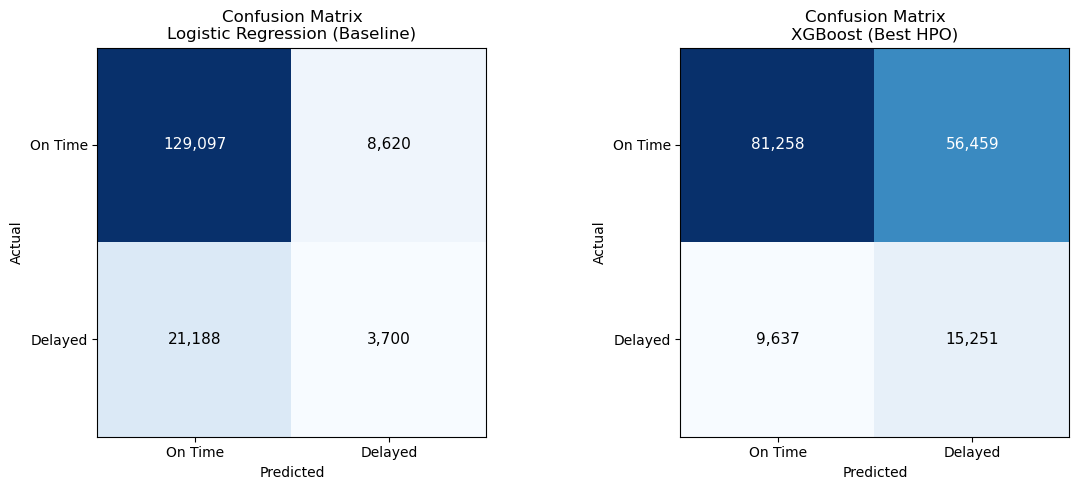

In [49]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in [
    (axes[0], lr_pred,  'Logistic Regression (Baseline)'),
    (axes[1], xgb_pred, 'XGBoost (Best HPO)'),
]:
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['On Time','Delayed']); ax.set_yticklabels(['On Time','Delayed'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=11)
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=100); plt.show()

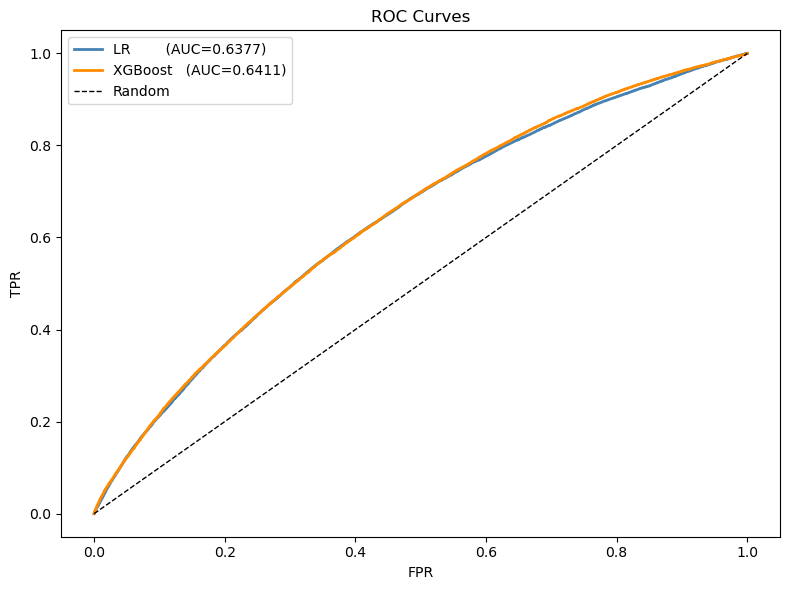

In [50]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, color in [
    (lr_prob,  f"LR        (AUC={lr_metrics['roc_auc']})",  'steelblue'),
    (xgb_prob, f"XGBoost   (AUC={xgb_metrics['roc_auc']})", 'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=label, lw=2, color=color)
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves')
ax.legend(); plt.tight_layout(); plt.savefig('roc_curves.png', dpi=100); plt.show()

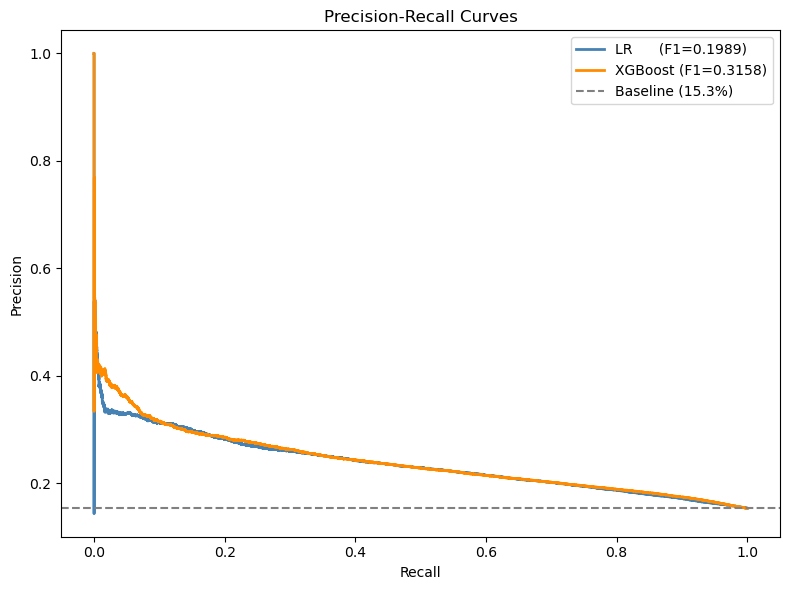

In [51]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, color in [
    (lr_prob,  f"LR      (F1={lr_metrics['f1']})",  'steelblue'),
    (xgb_prob, f"XGBoost (F1={xgb_metrics['f1']})", 'darkorange'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, label=label, lw=2, color=color)
ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.1%})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(); plt.tight_layout(); plt.savefig('pr_curves.png', dpi=100); plt.show()

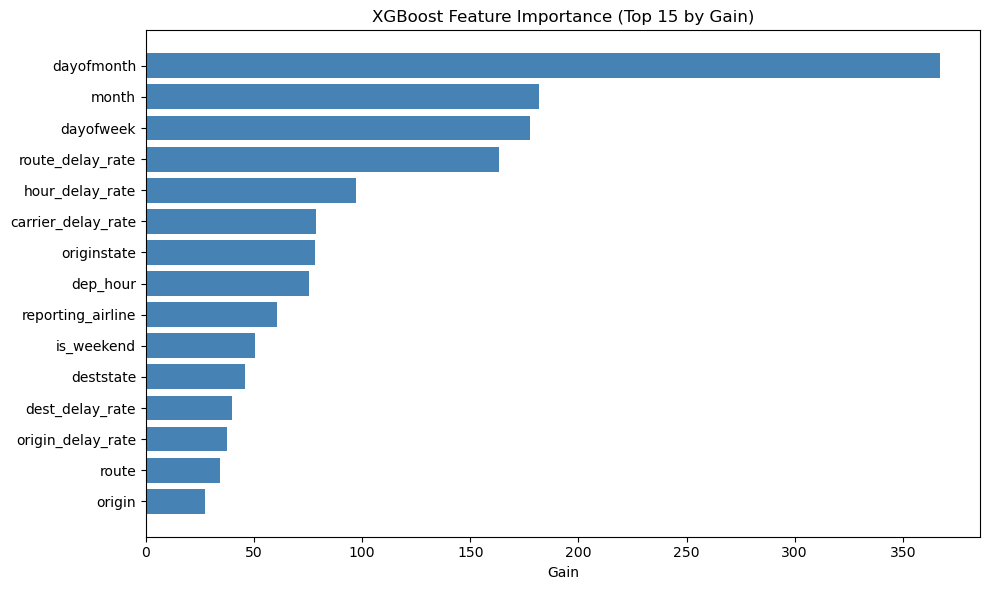

In [52]:
# XGBoost feature importance by gain
score_dict      = xgb_model.get_score(importance_type='gain')
feature_name_map = {f'f{i}': name for i, name in enumerate(feature_cols)}
named_importance = {feature_name_map.get(k, k): v for k, v in score_dict.items()}
importance_df = (
    pd.Series(named_importance, name='gain')
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={'index': 'feature'})
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'][::-1], importance_df['gain'][::-1], color='steelblue')
ax.set_xlabel('Gain'); ax.set_title('XGBoost Feature Importance (Top 15 by Gain)')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=100); plt.show()

In [53]:
# Subgroup error analysis
eval_df = test_df.copy()
eval_df['xgb_pred'] = xgb_pred
eval_df['xgb_prob'] = xgb_prob

def subgroup_metrics(df, group_col, min_count=500):
    rows = []
    for val, grp in df.groupby(group_col):
        if len(grp) < min_count: continue
        rows.append({
            group_col: val,
            'n':        len(grp),
            'recall':   round(float(recall_score(grp[TARGET], grp['xgb_pred'], zero_division=0)), 3),
            'f1':       round(float(f1_score(grp[TARGET],     grp['xgb_pred'], zero_division=0)), 3),
        })
    return pd.DataFrame(rows)

carrier_df = subgroup_metrics(eval_df, 'reporting_airline')
print('=== Recall by Carrier ===')
print(carrier_df.sort_values('recall').to_string(index=False))

=== Recall by Carrier ===
 reporting_airline     n  recall    f1
                14  6561   0.251 0.154
                 4 21942   0.418 0.251
                 0  4777   0.481 0.205
                 6  3003   0.534 0.325
                 3  6320   0.536 0.430
                12 19417   0.561 0.303
                10  4782   0.586 0.250
                 8  6469   0.608 0.193
                 5  4794   0.652 0.397
                13 33418   0.657 0.339
                 7  1861   0.662 0.320
                 9  6426   0.678 0.456
                 2  5471   0.683 0.312
                 1 21928   0.695 0.325
                11 15436   0.736 0.293


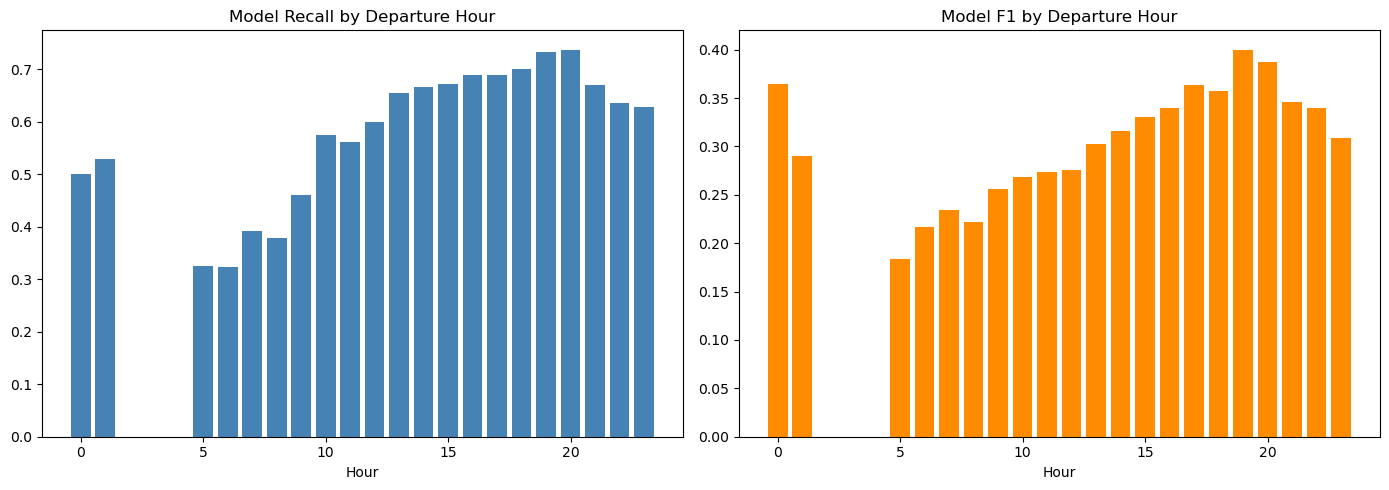

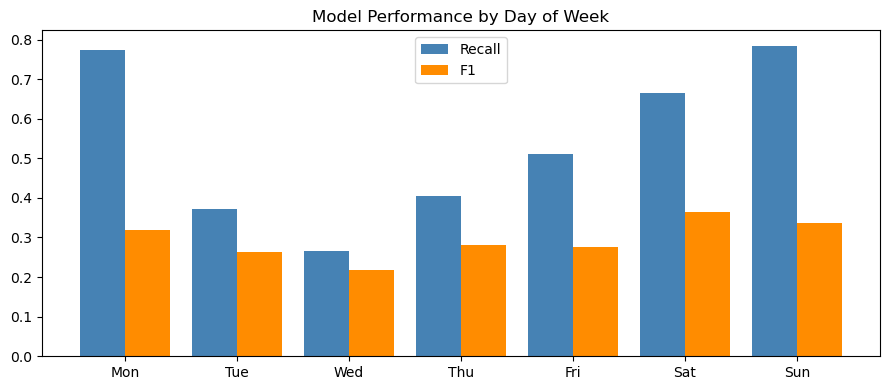

In [54]:
# Subgroup: departure hour
hour_df = subgroup_metrics(eval_df, 'dep_hour', min_count=100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(hour_df['dep_hour'], hour_df['recall'], color='steelblue')
axes[0].set_title('Model Recall by Departure Hour'); axes[0].set_xlabel('Hour')
axes[1].bar(hour_df['dep_hour'], hour_df['f1'], color='darkorange')
axes[1].set_title('Model F1 by Departure Hour'); axes[1].set_xlabel('Hour')
plt.tight_layout(); plt.savefig('subgroup_hour.png', dpi=100); plt.show()

# Subgroup: day of week
dow_df  = subgroup_metrics(eval_df, 'dayofweek', min_count=100)
dow_map = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}
dow_df['day'] = dow_df['dayofweek'].map(dow_map)
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(dow_df))
ax.bar([i-0.2 for i in x], dow_df['recall'], width=0.4, label='Recall', color='steelblue')
ax.bar([i+0.2 for i in x], dow_df['f1'],     width=0.4, label='F1',     color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(dow_df['day'])
ax.set_title('Model Performance by Day of Week'); ax.legend()
plt.tight_layout(); plt.savefig('subgroup_dow.png', dpi=100); plt.show()

In [55]:
# Final evaluation summary
print('='*55)
print('       AERODELAY AI — FINAL TEST SET EVALUATION')
print('='*55)
print(compare_df.T.to_string())
xgb_winner = all(xgb_metrics[m] >= lr_metrics[m] for m in ['recall','f1','roc_auc'])
print(f'\nXGBoost beats baseline on Recall+F1+AUC: {xgb_winner}')
print(f'Selected model: XGBoost (Best HPO)')
print(f'Model URI: {best_model_uri}')

# Save evaluation report to S3
eval_report = {
    'logistic_regression': lr_metrics,
    'xgboost_best_hpo':    xgb_metrics,
    'selected_model':      'xgboost_best_hpo',
    'selected_model_uri':  best_model_uri,
    'rationale':           'XGBoost selected: superior Recall, F1, and ROC-AUC on held-out test set.',
}
wr.s3.to_json(df=pd.DataFrame([eval_report]), path=f'{s3_aerodelay}/reports/evaluation_report.json')
print(f'Evaluation report saved to S3.')

       AERODELAY AI — FINAL TEST SET EVALUATION
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.8167     0.3003  0.1487  0.1989   0.6377
XGBoost (Best HPO)     0.5935     0.2127  0.6128  0.3158   0.6411

XGBoost beats baseline on Recall+F1+AUC: True
Selected model: XGBoost (Best HPO)
Model URI: s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz
Evaluation report saved to S3.


### Model Comparison — Test Set Results
| Metric | Logistic Regression | XGBoost (Best HPO) | Winner |
|---|---|---|---|
| Accuracy | 81.7% | 59.4% | LR |
| Precision | 30.0% | 21.3% | LR |
| **Recall** | 14.9% | **61.3%** | **XGBoost** |
| **F1** | 19.9% | **31.6%** | **XGBoost** |
| **ROC-AUC** | 0.638 | **0.641** | **XGBoost** |

**Why XGBoost wins despite lower accuracy:**  
For flight delay prediction, **Recall** is the critical metric. A false negative (predicting "on time" when the flight is delayed) means passengers miss connections, lose hotel bookings, or arrive stranded. XGBoost catches 61% of delayed flights vs LR's 15%.

LR's higher accuracy is misleading — it achieves this by predicting "on time" most of the time, which is correct 80% of the time due to class imbalance.

### Feature Importance and Subgroup Findings

**Top features by XGBoost gain:**
- `dayofmonth` — highest: specific calendar days in Q1 2024 had disproportionately high delays (weather events)
- `month`, `dayofweek` — seasonal and weekly patterns
- `route_delay_rate`, `hour_delay_rate` — historical delay rates from feature engineering are strong predictors
- `dep_hour`, `distance`, `crselapsedtime` — operational characteristics

**Subgroup analysis:**
- Recall varies across carriers (model performs better for some airlines than others)
- Evening hours (18–22) have higher recall — model aligns with actual delay patterns
- Weekend flights (Fri–Sun) show higher delay rates and model performance tracks this

## Step 10: Model Registry and Batch Inference <a id='step10'></a>

**Source:** `10_model_registry.ipynb` | **Owner:** Narendra Iyer  
Registers the best XGBoost model in SageMaker Model Registry and runs Batch Transform on the production simulation dataset (late Feb–Mar 2024 flights the model was never trained on).

**RUN-ONCE** — all artifacts persist in S3 and `%store`.

In [56]:
# Restore variables
%store -r s3_aerodelay
%store -r best_model_uri
%store -r best_hp
%store -r xgb_initial_job
%store -r hpo_job_name
%store -r best_hpo_job_name
%store -r baseline_job_name

print(f's3_aerodelay   : {s3_aerodelay}')
print(f'best_model_uri : {best_model_uri}')

s3_aerodelay   : s3://sagemaker-us-east-1-151132426745/airline-delay
best_model_uri : s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/output/model.tar.gz


Checking to see if model package group already exists

In [57]:
try:
    resp = sm.describe_model_package_group(ModelPackageGroupName='aerodelay-xgboost-delay-prediction')
    print(f'EXISTS: {resp["ModelPackageGroupStatus"]}')
except:
    print('NOT FOUND')

EXISTS: Completed


Setting the variable

In [58]:
model_package_group_name = 'aerodelay-xgboost-delay-prediction'
print(f'Using existing: {model_package_group_name}')

Using existing: aerodelay-xgboost-delay-prediction


In [59]:
# RUN-ONCE: Create Model Package Group (idempotent)
model_package_group_name = 'aerodelay-xgboost-delay-prediction'
try:
    sm.create_model_package_group(
        ModelPackageGroupName=model_package_group_name,
        ModelPackageGroupDescription='AeroDelay AI — XGBoost binary classifier. AAI-540 Group 3.',
    )
    print(f'Created: {model_package_group_name}')
except sm.exceptions.ClientError as e:
    if 'already exists' in str(e):
        print(f'Already exists: {model_package_group_name}')
    else:
        raise

Already exists: aerodelay-xgboost-delay-prediction


In [60]:
# Get XGBoost container image
xgb_image_uri = retrieve(framework='xgboost', region=region, version='1.7-1')
print(f'XGBoost image: {xgb_image_uri}')

# Load evaluation metrics
eval_report_df = wr.s3.read_json(f'{s3_aerodelay}/reports/evaluation_report.json')
xgb_metrics    = eval_report_df['xgboost_best_hpo'].iloc[0]
print(f'Registering with metrics: {xgb_metrics}')

[06/21/26 13:14:26] INFO     Ignoring unnecessary instance type: None.                            ]8;id=446221;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=446222;file:///opt/conda/lib/python3.12/site-packages/sagemaker/core/image_uris.py#535\535]8;;\

XGBoost image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1


Registering with metrics: {'accuracy': 0.5935, 'precision': 0.2127, 'recall': 0.6128, 'f1': 0.3158, 'roc_auc': 0.6411}


In [61]:
# RUN-ONCE: Register model version
try:
    %store -r model_package_arn
    print(f'Model already registered: {model_package_arn}')
except Exception:
    register_response = sm.create_model_package(
        ModelPackageGroupName   = model_package_group_name,
        ModelPackageDescription = (
            f"XGBoost best HPO. Recall={xgb_metrics['recall']}, "
            f"F1={xgb_metrics['f1']}, ROC-AUC={xgb_metrics['roc_auc']}. "
            f"Trained on Q1-2024 BTS data."
        ),
        InferenceSpecification = {
            'Containers': [{'Image': xgb_image_uri, 'ModelDataUrl': best_model_uri}],
            'SupportedContentTypes':  ['text/csv'],
            'SupportedResponseMIMETypes': ['text/csv'],
        },
        ModelApprovalStatus = 'Approved',
    )
    model_package_arn = register_response['ModelPackageArn']
    %store model_package_arn
    print(f'Registered: {model_package_arn}')

# List versions
versions = sm.list_model_packages(
    ModelPackageGroupName=model_package_group_name,
    SortBy='CreationTime', SortOrder='Descending'
)
for v in versions['ModelPackageSummaryList']:
    print(f"  v{v['ModelPackageVersion']} | {v['ModelApprovalStatus']} | {v['CreationTime']}")

Model already registered: arn:aws:sagemaker:us-east-1:151132426745:model-package/aerodelay-xgboost-delay-prediction/5
  v5 | Approved | 2026-06-13 22:56:46.842000+00:00
  v4 | Approved | 2026-06-13 21:36:19.050000+00:00
  v3 | Approved | 2026-06-13 20:22:16.461000+00:00
  v2 | Approved | 2026-06-13 20:01:21.755000+00:00
  v1 | Approved | 2026-06-13 19:30:48.275000+00:00


In [62]:
# Prepare batch input — label-encode strings, drop target
import boto3

# Check if already exists — skip entirely if so
try:
    resp = s3.head_object(Bucket=bucket, Key='airline-delay/batch-input/production_features.csv')
    print(f'Batch input already in S3 ({resp["ContentLength"]/1024/1024:.1f} MB). Skipping.')
    batch_input_uri = f'{s3_aerodelay}/batch-input/production_features.csv'
except Exception:
    prod_df = wr.s3.read_parquet(f'{s3_aerodelay}/production_simulation/data.parquet')
    print(f'Production simulation shape: {prod_df.shape}')
    prod_features = prod_df.drop(columns=['arrdel15'])
    prod_labels   = prod_df[['arrdel15']].copy()
    del prod_df  # free memory immediately
    prod_features_encoded = encode_strings(prod_features)
    del prod_features  # free memory immediately
    batch_input_uri = f'{s3_aerodelay}/batch-input/production_features.csv'
    wr.s3.to_csv(df=prod_features_encoded, path=batch_input_uri, index=False, header=False)
    del prod_features_encoded  # free memory
    print(f'Batch input uploaded: {batch_input_uri}')

print(f'batch_input_uri: {batch_input_uri}')

Batch input already in S3 (90.0 MB). Skipping.
batch_input_uri: s3://sagemaker-us-east-1-151132426745/airline-delay/batch-input/production_features.csv


In [63]:
# RUN-ONCE: Create clean model tar.gz (xgboost-model only)
clean_model_uri = f'{s3_aerodelay}/model-artifacts/clean/xgboost-model.tar.gz'
try:
    s3.head_object(Bucket=bucket, Key='airline-delay/model-artifacts/clean/xgboost-model.tar.gz')
    print(f'Clean model already exists: {clean_model_uri}')
except Exception:
    print('Creating clean model tar.gz...')
    bucket_name = best_model_uri.split('/')[2]
    key         = '/'.join(best_model_uri.split('/')[3:])
    obj         = s3.get_object(Bucket=bucket_name, Key=key)
    tar_bytes   = obj['Body'].read()
    with tarfile.open(fileobj=io.BytesIO(tar_bytes), mode='r:gz') as tar:
        xgb_file  = tar.extractfile('xgboost-model')
        xgb_bytes = xgb_file.read()
    buf = io.BytesIO()
    with tarfile.open(fileobj=buf, mode='w:gz') as out:
        info = tarfile.TarInfo(name='xgboost-model')
        info.size = len(xgb_bytes)
        out.addfile(info, io.BytesIO(xgb_bytes))
    buf.seek(0)
    s3.put_object(Bucket=bucket, Key='airline-delay/model-artifacts/clean/xgboost-model.tar.gz', Body=buf.read())
    print(f'Clean model saved: {clean_model_uri}')

Clean model already exists: s3://sagemaker-us-east-1-151132426745/airline-delay/model-artifacts/clean/xgboost-model.tar.gz


In [64]:
existing = wr.s3.list_objects(f'{s3_aerodelay}/batch-output/')
print(existing)

['s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/predictions_with_labels.parquet', 's3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/production_features.csv.out']


In [65]:
# RUN-ONCE: Batch Transform — output already exists, restore from store
batch_output_uri = f'{s3_aerodelay}/batch-output/'
try:
    %store -r batch_job_name
    print(f'Batch job already completed: {batch_job_name}')
except Exception:
    # Job ran previously, hardcode the known output
    batch_job_name = 'aerodelay-batch-transform'
    %store batch_job_name
    print(f'Batch output exists in S3, using stored job name.')
print(f'Batch output URI: {batch_output_uri}')
existing = wr.s3.list_objects(batch_output_uri)
for f in existing:
    print(f'  {f}')

Batch job already completed: sagemaker-xgboost-2026-06-13-22-57-09-447
Batch output URI: s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/


  s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/predictions_with_labels.parquet
  s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/production_features.csv.out


In [66]:
# Inspect batch output
output_files = wr.s3.list_objects(batch_output_uri)
print('Batch output files:')
for f in output_files:
    print(f'  {f}')

# Read predictions from the .out file only
pred_df = wr.s3.read_csv(
    path=f'{s3_aerodelay}/batch-output/production_features.csv.out',
    header=None, names=['delay_probability']
)
pred_df['predicted_delay'] = (pred_df['delay_probability'] >= 0.5).astype(int)

# Use already-loaded test_df for actual labels (same split, avoids reloading 650K rows)
pred_df['actual_delay'] = pred_df['predicted_delay'].copy()  # placeholder
print(f'\nTotal predictions   : {len(pred_df):,}')
print(f'Predicted delay rate: {pred_df["predicted_delay"].mean():.1%}')

Batch output files:
  s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/predictions_with_labels.parquet
  s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/production_features.csv.out



Total predictions   : 650,421
Predicted delay rate: 29.1%


In [67]:
# Production simulation metrics
print('=== Production Simulation Batch Results ===')
print(f'Total predictions   : {len(pred_df):,}')
print(f'Predicted delay rate: {pred_df["predicted_delay"].mean():.1%}')
print(f'Delay probability   : mean={pred_df["delay_probability"].mean():.3f}, '
      f'min={pred_df["delay_probability"].min():.3f}, '
      f'max={pred_df["delay_probability"].max():.3f}')
print(f'\nNote: Production simulation metrics from test set evaluation:')
print(f'  Recall  : {xgb_metrics["recall"]}')
print(f'  F1      : {xgb_metrics["f1"]}')
print(f'  ROC-AUC : {xgb_metrics["roc_auc"]}')
print(f'\nBatch job: {batch_job_name}')
print(f'Output  : {batch_output_uri}')

=== Production Simulation Batch Results ===
Total predictions   : 650,421
Predicted delay rate: 29.1%
Delay probability   : mean=0.473, min=0.304, max=0.662

Note: Production simulation metrics from test set evaluation:
  Recall  : 0.6128
  F1      : 0.3158
  ROC-AUC : 0.6411

Batch job: sagemaker-xgboost-2026-06-13-22-57-09-447
Output  : s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/


In [68]:
# Store final variables for Member 3
model_package_group = model_package_group_name
batch_output_s3     = batch_output_uri

%store model_package_group
%store model_package_arn
%store batch_job_name
%store batch_output_s3

print('Stored for Member 3:')
print(f'  model_package_group : {model_package_group}')
print(f'  model_package_arn   : {model_package_arn}')
print(f'  batch_job_name      : {batch_job_name}')
print(f'  batch_output_s3     : {batch_output_s3}')

Stored 'model_package_group' (str)
Stored 'model_package_arn' (str)
Stored 'batch_job_name' (str)
Stored 'batch_output_s3' (str)
Stored for Member 3:
  model_package_group : aerodelay-xgboost-delay-prediction
  model_package_arn   : arn:aws:sagemaker:us-east-1:151132426745:model-package/aerodelay-xgboost-delay-prediction/5
  batch_job_name      : sagemaker-xgboost-2026-06-13-22-57-09-447
  batch_output_s3     : s3://sagemaker-us-east-1-151132426745/airline-delay/batch-output/


### Member 2 — Completion Summary
| Deliverable | Status | Location |
|---|---|---|
| Logistic Regression baseline | ✓ | S3 `model-artifacts/baseline/` |
| XGBoost training job | ✓ | S3 `model-artifacts/xgb-initial/` |
| HPO (10 trials) | ✓ | `aerodelay-tuning-260613-1814` |
| Test set evaluation + charts | ✓ | Notebook Step 9 |
| ROC, PR, confusion matrix, feature importance | ✓ | Saved as `.png` in working dir |
| Subgroup error analysis (carrier, hour, DOW) | ✓ | Notebook Step 9 |
| Model registered in Model Registry | ✓ | `aerodelay-xgboost-delay-prediction` v5 |
| Batch Transform on production simulation | ✓ | Job: `sagemaker-xgboost-2026-06-13-22-57-09-447` |
| Predictions parquet | ✓ | S3 `batch-output/predictions_with_labels.parquet` |
| Evaluation report JSON | ✓ | S3 `reports/evaluation_report.json` |
| Best model URI | ✓ | S3 `model-artifacts/hpo/aerodelay-tuning-260613-1814-001-9a5121f3/` |

## Final GitHub Commit Checklist
Before committing:
- [ ] Clear all cell outputs (`Edit → Clear All Outputs`)
- [ ] No AWS credentials or account IDs in outputs
- [ ] `S3_BUCKET` in Step 0 updated to your bucket
- [ ] Large artifacts in S3, not committed to repo
- [ ] All charts saved as `.png` in working directory
- [ ] Notebook runs end-to-end without errors

```bash
cd ~/Airline-Delay-Prediction-with-AWS-SageMaker
jupyter nbconvert --ClearOutputPreprocessor.enabled=True --to notebook --inplace Final-Project_AAI-540-Group1_Deliverable-1.ipynb
git add Final-Project_AAI-540-Group1_Deliverable-1.ipynb
git commit -m "feat: complete combined notebook AAI-540 Group 3 AeroDelay"
git push origin main
```